### Deeptools PlotCorrelation Choices Explanation

In order to generate distance plots of the correlation coefficients between the samples, I used the Pearson method. Since the MultiQC report showed that the samples follow a normal distribution pattern (as seen with the GC content per sample) I decided that Pearson would be best. The heatmap created by implementing the pearson method makes sense since it strongly clusters the control and experimental replicates together

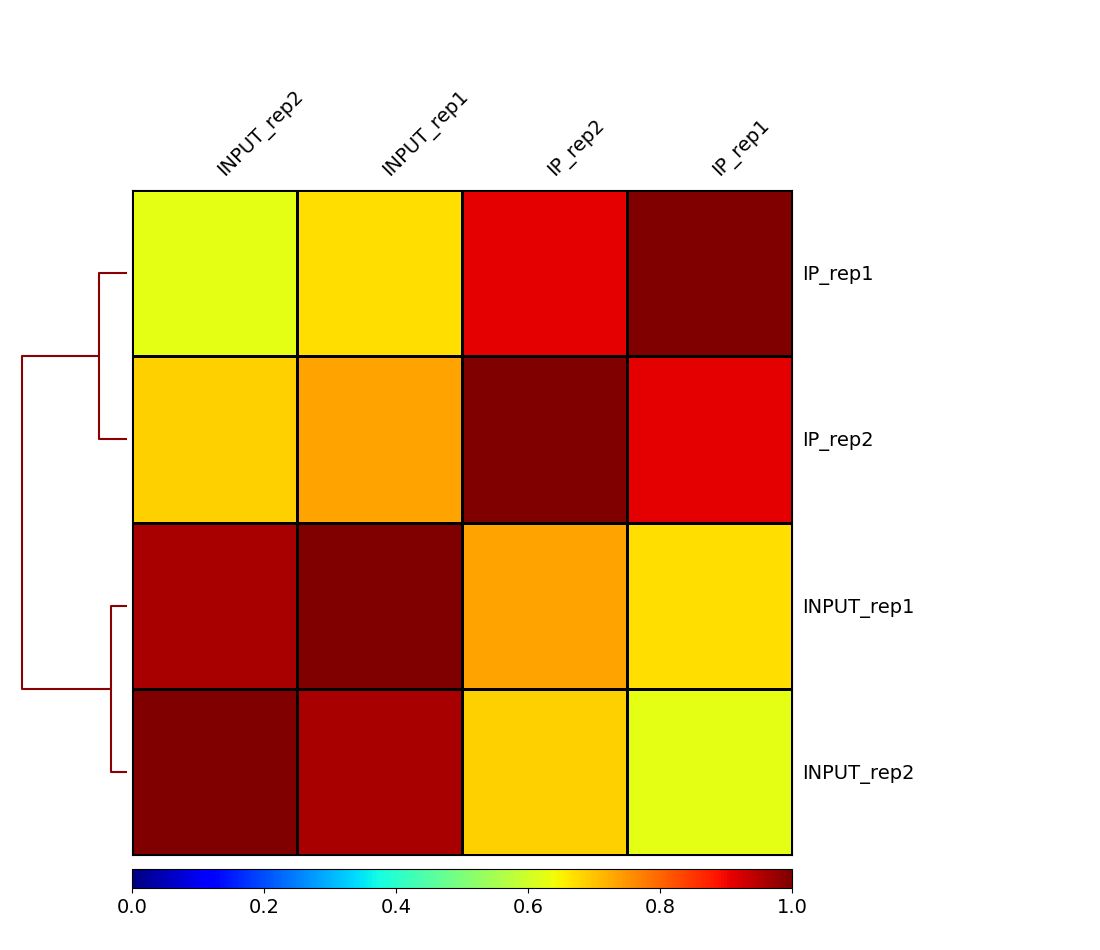

### Bedtools Intersect Choices Explanation
For choosing consensus peaks, I used a stricter filter of 50% overlap between the peaks. I did this because we want these consensus peaks to be accurate and reliable. If we did an overlap of 1bp, that wouldn't give us much information. Requiring at least 50% will provide us with peaks that have a substantial amount of overlap that we can be confident in.

### Blacklist Regions Filtering Explanation
Since we wanted to remove the ENCODE blacklist region from our consensus peak, I used the -v flag in bedtools intersect. This flag keeps the peaks in the consensus peaks that are NOT in the ENCODE blacklist. You do have to specify the files for the the consensus peaks and then the blacklist region.

### Deeptools ComputeMatrix and PlotProfile Discussion

For both of these replicates we observe signals around the transcription start site (TSS). This signal corresponds to enrichment of specific regions in the genome (primarily the TSS), which suggests that there is some sort of modification the genome around this region. This makes sense since the TSS is a standard binding site for proteins. Genes that have significant signal around the TSS may be more actively transcribed than in other conditions. It would be interesting to compare this to the INPUT replicates, but they will increase the noise in the analysis. These plots were created by comparing the experimental regions with reference regions (from UCSC Table Browser) and calculating values that are representative of the signal in these experimental regions. The regions we are looking cover 2000bp up- and down-stream of the TSS and TES for the genes.

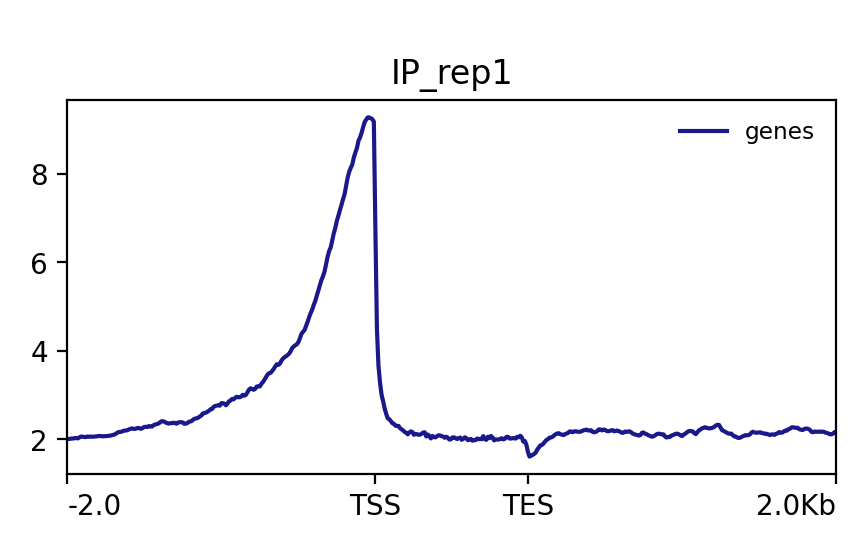
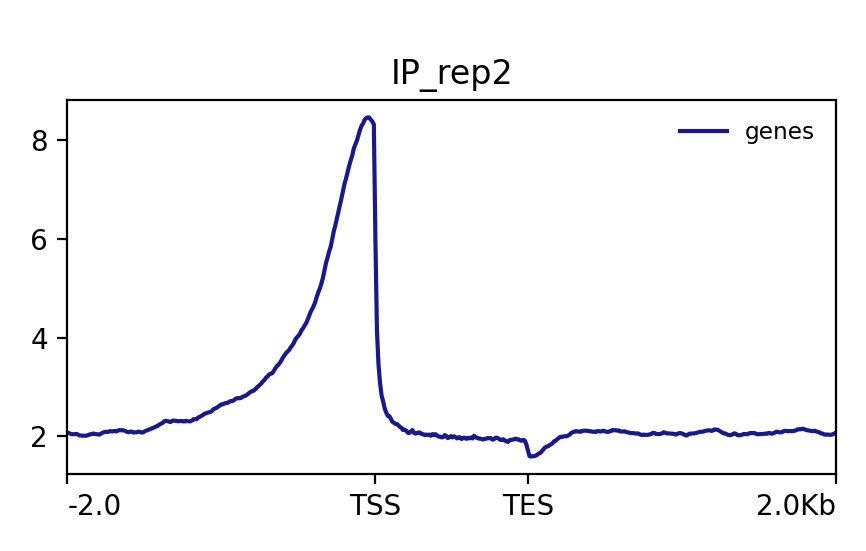

### Homer findMotifsGenome.pl Results Discussion
It appears that the first five motifs are very significant (p < 1e-50), which is a good indicator of the experimental success. Motifs with a p-value greater than 1e-50 may be indicative of issues with the experiment or it could simply explain that those factors are not highly expressed. These significant motifs should correlate to binding sites for our factor of interest's DNA binding domain. 

Based on my research of these transcription factors, many are involved in regulating development and cell cycle stages. The most significant motif correlates to a TF that is involved in regulating bone and cartilage development. If the TFs aren't directly linked to development, they tend to affect other processes during development. These results signal to me that our experiment is interested in understanding regulation mechanisms of development.

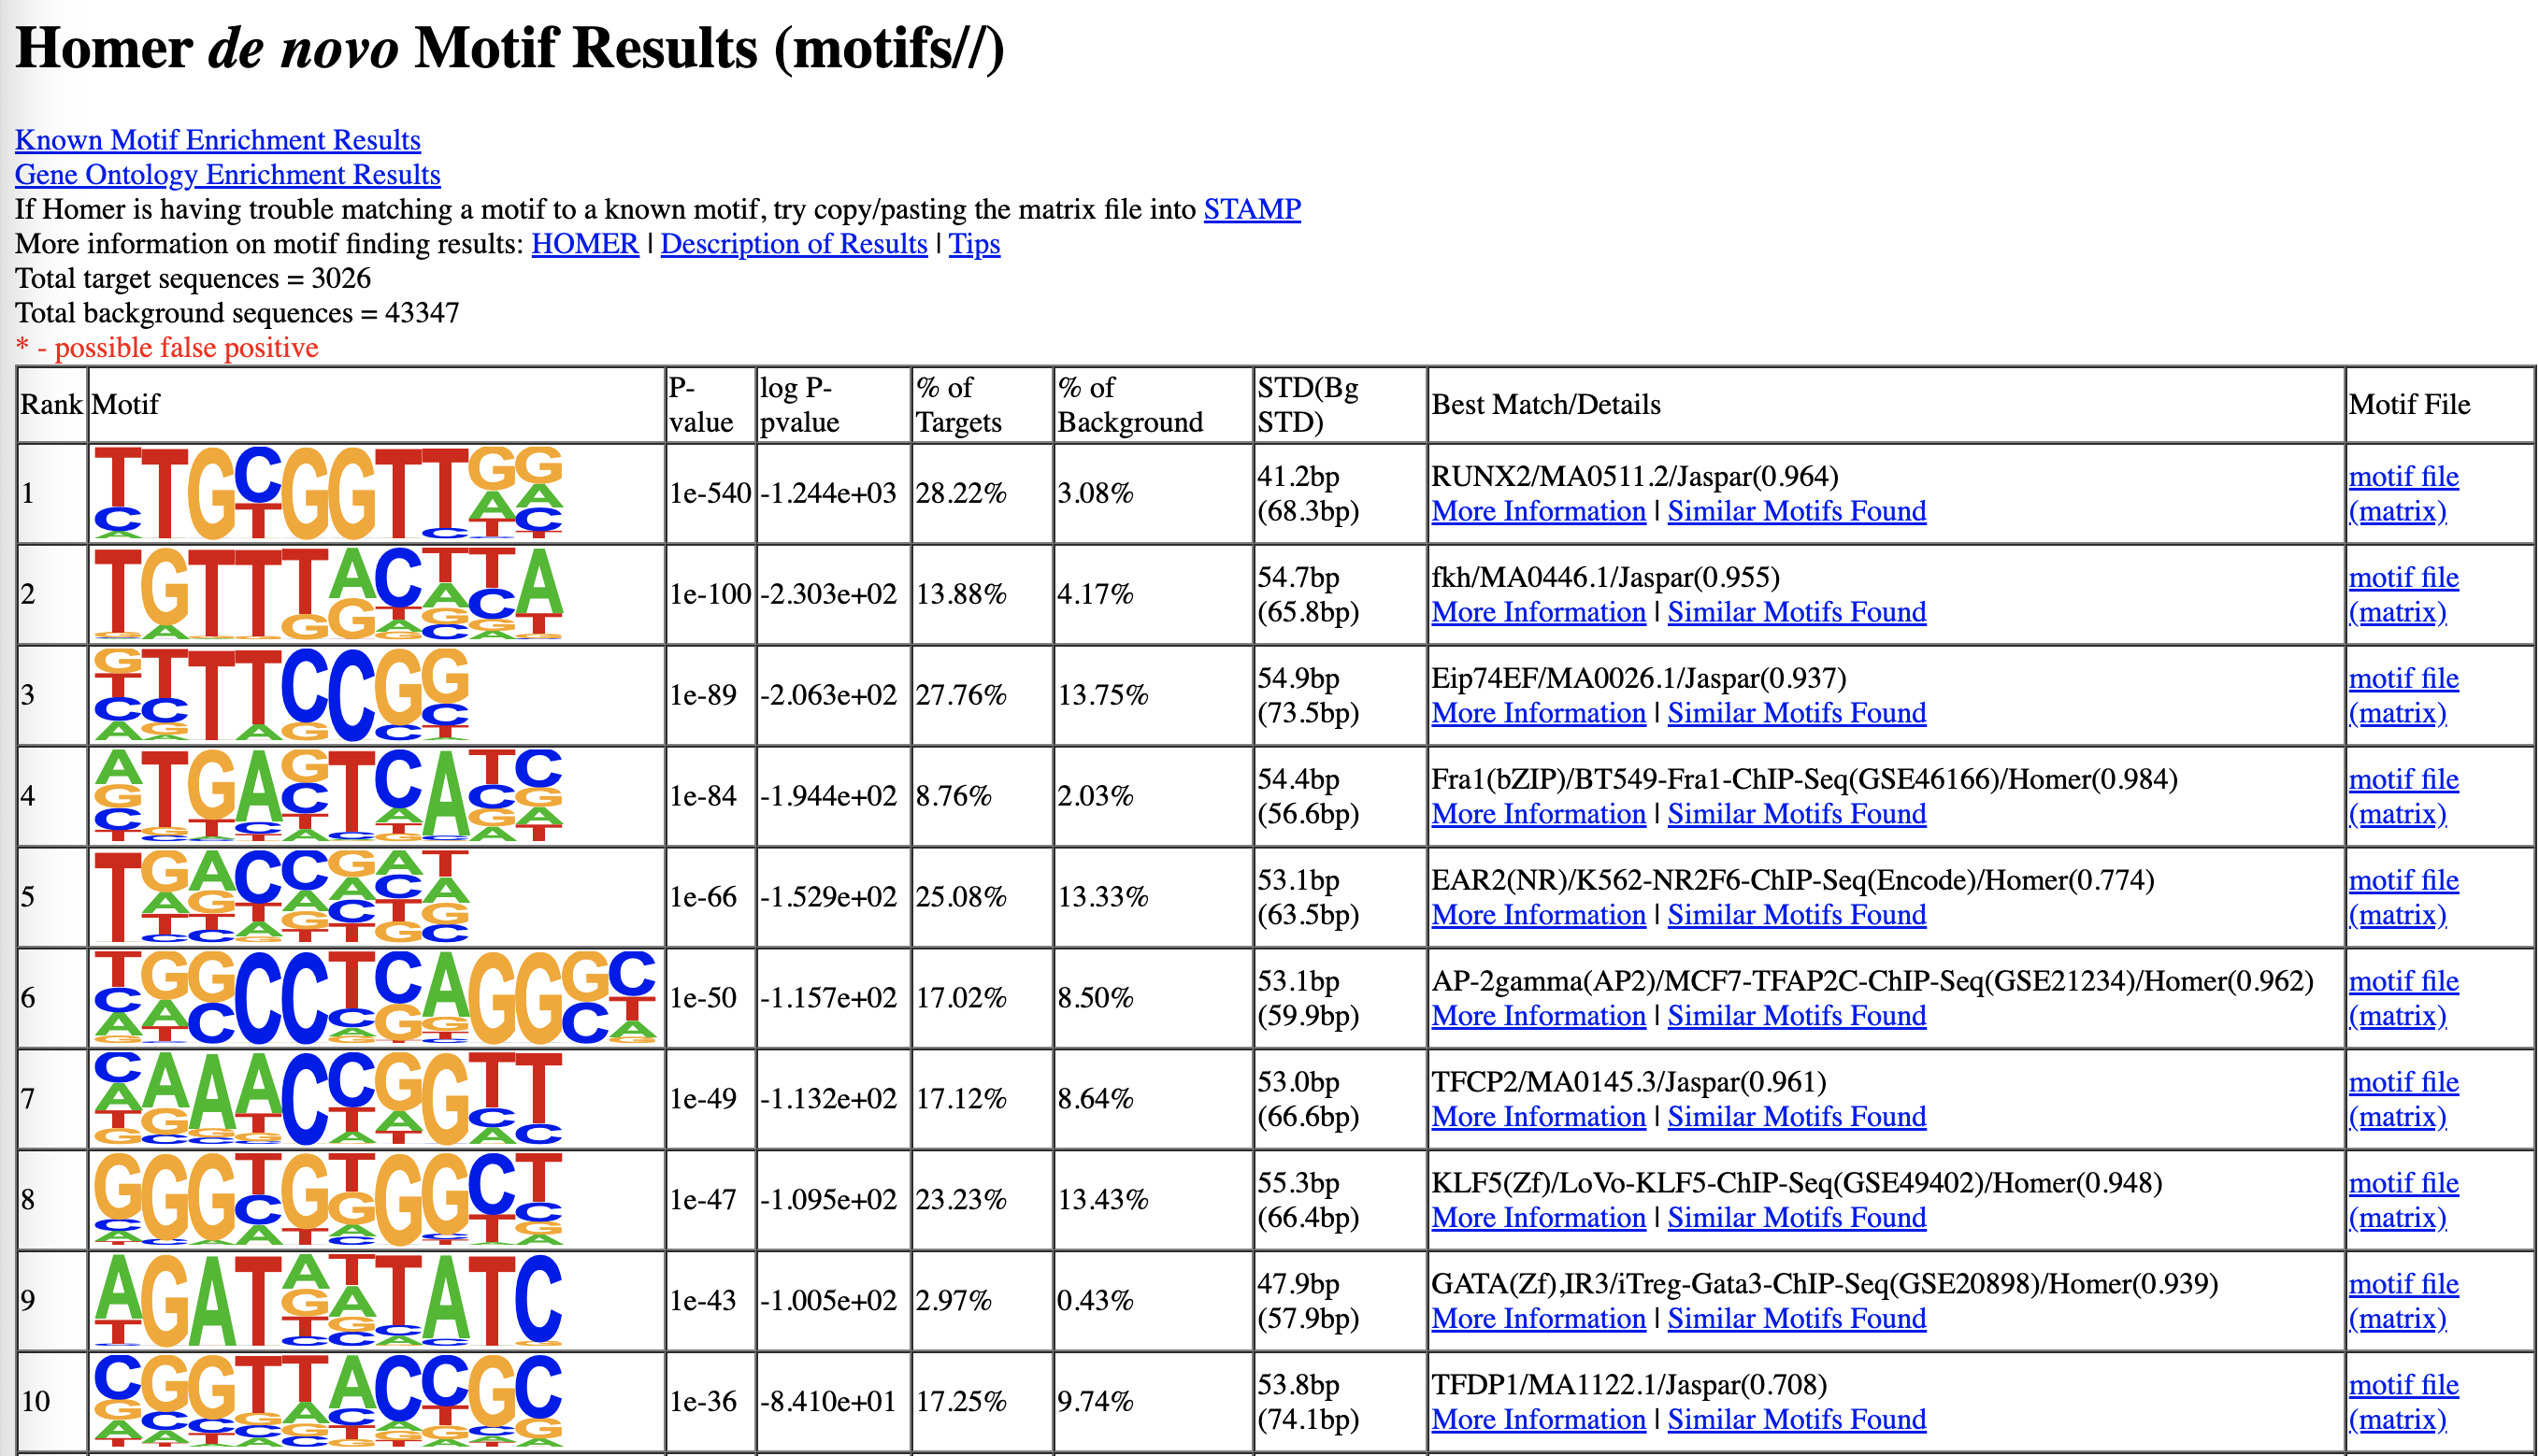

### Methods

#### QC to Peak Calling
These samples were provided by the researchers on NCBI GEO under the accession code GSE75070. We first looked into the quality of the sample reads using FastQC. From there, low quality samples and adapters were trimmed using Trimmomatic and the default parameters. Using bowtie2, we aligned the samples the GRCh38 (gencode 47) human reference genome. After alignment, we did further quality control with samtools flagstat utility. The qualtiy control metrics were concatenated into a MultiQC report. Peaking calling was conducted using MACS3 and the default parameters. Next, bedtools intersect was used to create consensus peaks that had a 50% overlap. Then, any peaks that belong to the Blacklist created by the Boyle Lab were removed from the reproductible peaks. Finally, peak annotation and motif finding occured using HOMER.

#### Files and Figure Generation
The BAM files created by the samtools indexing were used by Deeptools bamCoverage to create the bigWig files. Correlation plots that illistrate the similarity among the samples and replicates were created using Deeptools plotCorrelation, these were created from the multiBigWigSummary. We used the UCSC genome browser to obtain the genomic coordinates of the hg38 genes from the human (GRCh38, Dec 2013) RefSeq annotations. Then, with 2000bp padding up- and down-stream of the TSS and TES, we used computeMatrix and plotProfile to understand the signal around the promoter regions and throughout the genes.



### MultiQC Commentary

The MultiQC reports show that the experimental data looks suitable for analysis. One worry point is the number of duplicate reads. Duplicates can cause false signals and incorrect peak calling, such that the analysis might reveal more signficant peaks than there truly are. Additionally, there is some concern with the presence of overrepresented sequences, which can cause false positives as well. However, that might be a true signal and these regions actually have increased enrichment. Based on these two flags, I would continue with the analysis since yes these flags may cause false positives, but since we are seeing them in our experimental (IP) samples they may indicate true signal, true enrichment.

### Overlap Results - RNAseq DE and ChIPseq Peaks

The researchers used a p-value of 0.01 and a log2FC of 1 to qualify genes as being differentially expressed. I will use these same thresholds in my analysis and interpretation. 

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [33]:
rnaseq = pd.read_csv('results/GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.txt', sep='\t')
peaks = pd.read_csv('results/annotated_peaks.txt', sep='\t')

In [5]:
rnaseq.head()

,genename,transcript,log2FoldChange,padj
0,OARD1,NM_145063,0.186841,0.545806
1,WBSCR22,"NM_001202560,NM_017528,NR_037776,NR_045512",0.037881,0.907305
2,PIGZ,NM_025163,0.122346,0.841445
3,PRDX5,"NM_012094,NM_181651,NM_181652",0.250313,0.118073
4,PEX16,"NM_004813,NM_057174",-0.300675,0.183572


In [6]:
peaks.head()

,PeakID (cmd=annotatePeaks.pl refined_peaks.bed GRCh38.primary_assembly.genome.fa -gtf gencode.v45.primary_assembly.annotation.gtf),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
0,rep1_peak_933,chr1,146228817,146229331,+,3013,NaN,promoter-TSS (ENST00000362074.8),protein_coding-promoter-TSS (ENST00000362074.8),-33.0,ENST00000687833.1,ENSG00000264343,ENST00000686973,NaN,NaN,NOTCH2NLA,NaN,NaN,protein_coding
1,rep1_peak_956,chr1,148679264,148680120,+,2856,NaN,promoter-TSS (ENST00000593495.4),protein_coding-promoter-TSS (ENST00000593495.4),50.0,ENST00000606877.2,ENSG00000270629,ENST00000619423,NaN,NaN,NBPF14,NaN,NaN,protein_coding
2,rep1_peak_967,chr1,149390247,149390764,+,2435,NaN,promoter-TSS (ENST00000621744.4),protein_coding-promoter-TSS (ENST00000621744.4),-116.0,ENST00000650865.2,ENSG00000286219,ENST00000650865,NaN,NaN,NOTCH2NLC,NaN,NaN,protein_coding
3,rep1_peak_740,chr1,120069178,120070015,+,2198,NaN,promoter-TSS (ENST00000256646.7),protein_coding-promoter-TSS (ENST00000256646.7),20.0,ENST00000652302.1,ENSG00000134250,ENST00000640021,NaN,NaN,NOTCH2,NaN,NaN,protein_coding
4,rep1_peak_3996,chr15,70462699,70463421,+,1900,NaN,Intergenic,Intergenic,42868.0,ENST00000559752.1,ENSG00000259473,ENST00000559752,NaN,NaN,LINC02205,NaN,NaN,lncRNA


#### Figure 2F

I think it is interesting how my results are so drastically different from the researchers. They had a significantly greter total of up- and down-regulated genes for each of the different up- and down-stream boundaries (5kb and 20kb). One similarity, is that the number of DE genes is greater with a broader range (20kb). One reason might be that they used other covariates to filter their genes, which would've made them less stringent and had more DE genes. Combining these two analyses allow us to understand the correlation between histone modifications (histones might be more open) and where transcription is being enhanced. The peaks we see that cover DE genes can validate that there is a modification going on (an interaction with a TF) that is causing a certain set of genes to be differentially expressed. 

687 Upregulated Genes

466 Downregulated Genes

In [12]:
# Find up- and down-regulated genes
upreg = rnaseq.loc[(rnaseq['padj'] < 0.01) & (rnaseq['log2FoldChange'] > 1)]
downreg = rnaseq.loc[(rnaseq['padj'] < 0.01) & (rnaseq['log2FoldChange'] < -1)]

In [17]:
# Convert to list
upreg_genes = upreg['genename'].tolist()
downreg_genes = downreg['genename'].tolist()

In [13]:
upreg

,genename,transcript,log2FoldChange,padj
48,SGOL1,"NM_001012409,NM_001012410,NM_001012411,NM_0010...",1.865109,7.048718e-16
50,MYCN,"NM_001293228,NM_001293231,NM_001293233",1.961676,9.265427e-05
66,INCENP,"NM_001040694,NM_020238",1.635607,3.296986e-14
80,VCAN,"NM_001126336,NM_001164097,NM_001164098,NM_004385",2.010163,1.561000e-06
86,TPI1,"NM_001159287,NM_001258026",1.052948,9.799512e-11
...,...,...,...,...
15256,PCDHAC2,"NM_018899,NM_031883",1.590426,1.305452e-07
15274,TCF19,"NM_001077511,NM_007109",1.684759,1.205806e-18
15282,NEK2,"NM_001204182,NM_001204183,NM_002497",1.349700,1.898691e-05
15335,SMAD9,"NM_001127217,NM_005905",1.333194,8.277110e-03


In [14]:
downreg

,genename,transcript,log2FoldChange,padj
39,CYSRT1,NM_199001,-1.179227,6.910866e-04
139,AGAP9,"NM_001190810,NM_001190810_chr10:47191843_47213626",-1.179856,2.622705e-04
146,TM2D1,NM_032027,-1.120710,2.415048e-07
162,SEMA4C,NM_017789,-1.480403,4.369624e-13
206,CCDC78,NM_001031737,-1.080449,1.883375e-03
...,...,...,...,...
15330,UCKL1-AS1,NR_027287,-1.222779,2.415494e-04
15343,SCARNA12,NR_003010,-1.013360,2.225647e-08
15367,TM4SF1,NM_014220,-2.659629,1.184314e-13
15381,PAN2,"NM_001127460,NM_001166279,NM_014871",-1.394833,1.368096e-28


In [18]:
# Find up- and down-regulated genes in the Annotated Peaks
up_peaks = peaks.query('`Gene Name` in @upreg_genes')
down_peaks = peaks.query('`Gene Name` in @downreg_genes')

In [19]:
# Find peaks within +/-5kb or +/-20kb of the DE genes
up_5kb = up_peaks[(up_peaks['Distance to TSS'] < 5000) & (up_peaks['Distance to TSS'] > -5000)].shape[0]
down_5kb = down_peaks[(down_peaks['Distance to TSS'] < 5000) & (down_peaks['Distance to TSS'] > -5000)].shape[0]

up_20kb = up_peaks[(up_peaks['Distance to TSS'] < 20000) & (up_peaks['Distance to TSS'] > -20000)].shape[0]
down_20kb = down_peaks[(down_peaks['Distance to TSS'] < 20000) & (down_peaks['Distance to TSS'] > -20000)].shape[0]

# Set up data for plotting
regulation = {
    '+/- 5kb of TSS': {
        'Upregulated': up_5kb,
        'Downregulated': down_5kb
    },
    '+/- 20kb of TSS': {
        'Upregulated': up_20kb,
        'Downregulated': down_20kb
    }
}

categories = list(regulation.keys())
upregulated = [regulation[cat]['Upregulated'] for cat in categories]
downregulated = [regulation[cat]['Downregulated'] for cat in categories]

In [22]:
regulation

{'+/- 5kb of TSS': {'Upregulated': 43, 'Downregulated': 33},
 '+/- 20kb of TSS': {'Upregulated': 56, 'Downregulated': 38}}

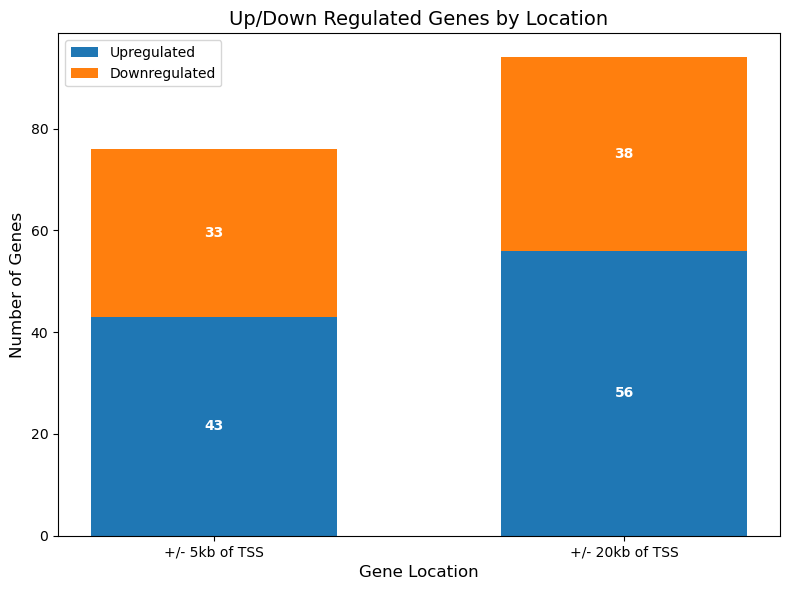

In [21]:
plt.figure(figsize=(8, 6))

# Create the stacked bars
positions = [0, 1]  # One position for each category (Upstream, Downstream)
bar_width = 0.6

# Plot upregulated genes (bottom part of bars)
p1 = plt.bar(positions, upregulated, bar_width, 
             label='Upregulated', color='#1f77b4')

# Plot downregulated genes on top of upregulated (note the bottom parameter)
p2 = plt.bar(positions, downregulated, bar_width, 
             bottom=upregulated, label='Downregulated', color='#ff7f0e')

# Customize the plot
plt.xlabel('Gene Location', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.title('Up/Down Regulated Genes by Location', fontsize=14)
plt.xticks(positions, categories)
plt.legend()

# Add value labels on top of each bar segment
for i in range(len(categories)):
    plt.text(i, upregulated[i]/2, str(upregulated[i]), 
             ha='center', va='center', color='white', fontweight='bold')
    plt.text(i, upregulated[i] + downregulated[i]/2, str(downregulated[i]), 
             ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

#### Figure 2D/2E
The top figure is a reproduction of figure 2D from the paper. Here we also see two signficant peaks that are a smidge-more downstream of the gene than they are in the paper, but they are still present. The peaks for figure 2D look very similar to the paper. 

The bottom figure is a reproduction of figure 2E from the paper. Here we also see two signficant peaks that are a bit more downstream of the gene than they are in the paper, but they are still present and significant. 

Overall, my genomic tracks figures are similar to the papers. They have observable similarities in spread of peaks. There are differences in the amplitude of the peaks, but that might be due to the researcher's further normalizing their peaks. 

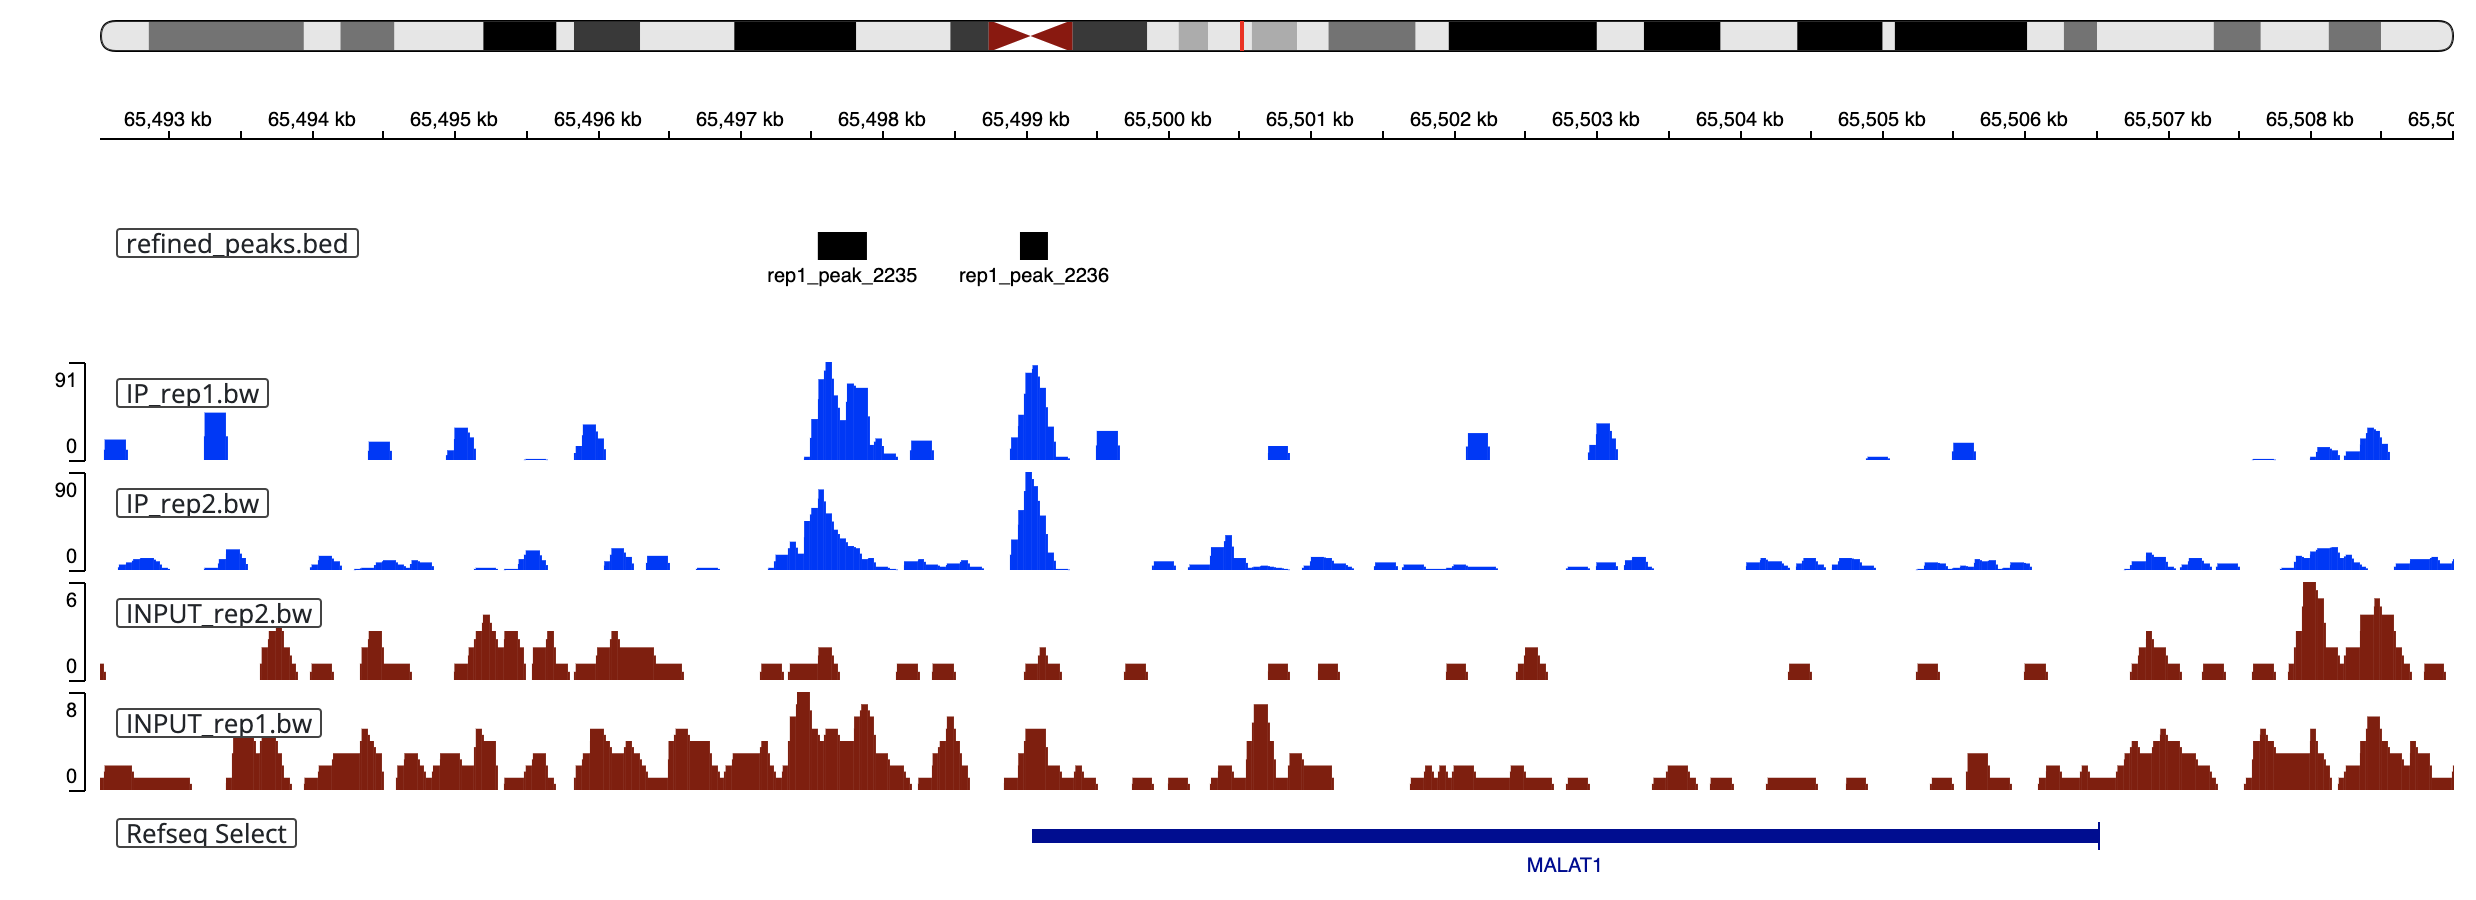

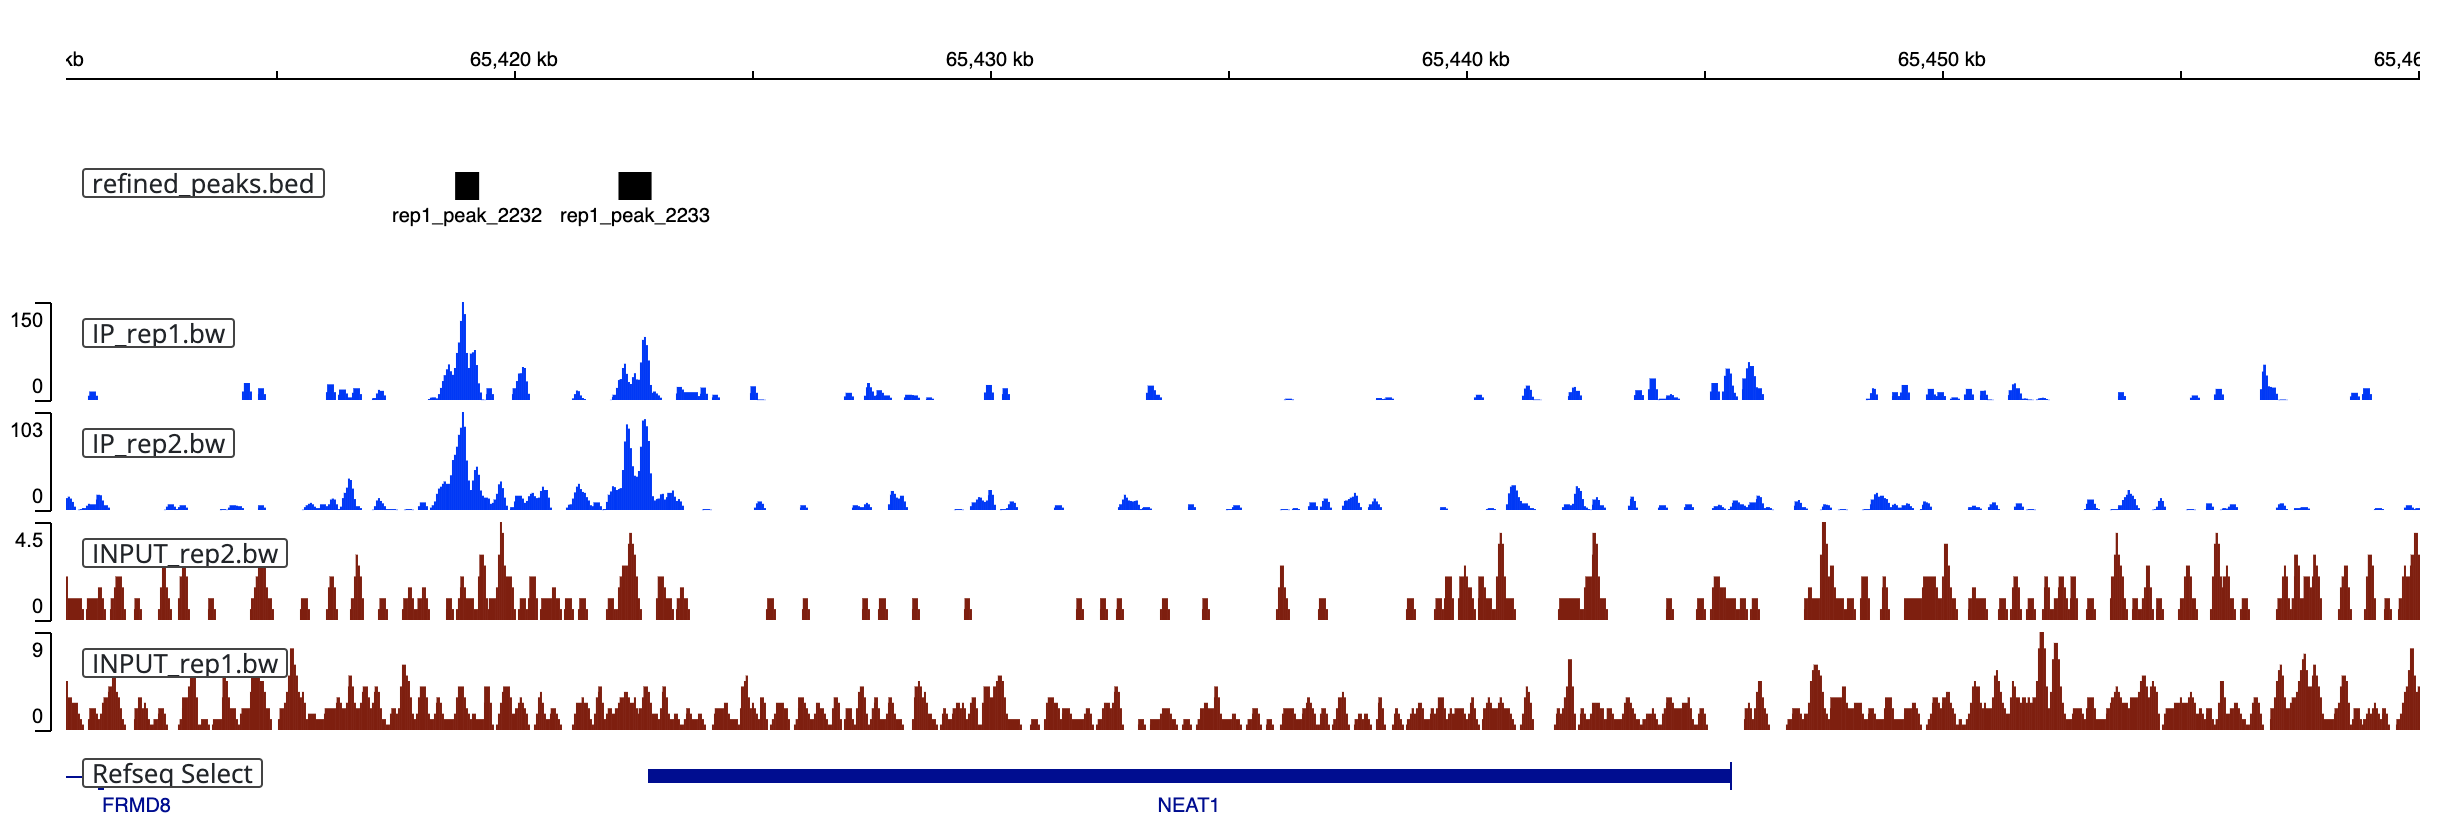

### Compare Key Findings

#### Figure S2A

##### Methodology
Gathered number of raw and mapped reads from visually inspecting the sample_id_flagstat.txt files for each sample

##### Explanation
A consistent difference between my results table and the researcher's is that their number of mapped reads is much lower than mine for each sample. One difference might be in our alignment tools, I used Bowtie2, which might not be as stringent as the aligner the researchers used, Bowtie2 might've allowed for mismatches. Additionally, we didn't go over normalization techniques for the reads, so the samples might've been normalized when the researchers did their analysis. 

In [10]:
input1_raw = 30075142
input1_map = 28253593
input2_raw = 10900442
input2_map = 10069440

ip1_raw = 29734121
ip1_map = 27969494
ip2_raw = 29988988
ip2_map = 28351783

In [14]:
replicate_reads = {
    'Sample Name': ['IP_rep1', 'IP_rep2', 'INPUT_rep1', 'INPUT_rep2'],
    'Biological Replicate': [1,2,1,2],
    'Raw Reads': [ip1_raw, ip2_raw, input1_raw, input2_raw],
    'Mapped Reads': [ip1_map, ip2_map, input1_map, input2_map]
}

reads = pd.DataFrame(replicate_reads)

reads

,Sample Name,Biological Replicate,Raw Reads,Mapped Reads
0,IP_rep1,1,29734121,27969494
1,IP_rep2,2,29988988,28351783
2,INPUT_rep1,1,30075142,28253593
3,INPUT_rep2,2,10900442,10069440


#### Figure S2B

The authors observed strong signal clustering within the control and experimental replicates, this indicates there is strong similarity among the replicates, which is a good sign – shows that the data was reliable and not a one-off fluke. I observed the same with my figure and samples. There are no singificant observable differences between our two figures and the clusters we obtained.

#### Figure S2C
The results I found for the number of peaks that unique to replicate 1 and replicate 2 are drastically different from the paper's figure. My number of called peaks are substantially greater than the paper's results. For my analysis, I used MACS3 that might have a less stringent p-value to determine which peaks are significant than the researcher's methodology. A less stringent p-value can allow more peaks to be called with less confidence. Additionally, MACS3 calls the peaks and pushes the replicates together (for the experimental and control), which allows us to retain lower-abundance peaks that their peak caller might not retain if they push their replicates together in a separate step before peakcalling.

In [18]:
# number of peaks for rep 1
!wc -l /projectnb/bf528/materials/project-2-chipseq/refs/rep1_peaks.narrowPeak

# number of peaks for rep 2
!wc -l /projectnb/bf528/materials/project-2-chipseq/refs/rep2_peaks.narrowPeak

# number of peaks shared by both
!wc -l results/refined_peaks.bed

13161 /projectnb/bf528/materials/project-2-chipseq/refs/rep1_peaks.narrowPeak
17440 /projectnb/bf528/materials/project-2-chipseq/refs/rep2_peaks.narrowPeak
3026 results/refined_peaks.bed


In [22]:
# number of unique rep 1 (total - shared)
unique_rep1 = 13161 - 3026

# number of unique rep 2 (total - shared)
unique_rep2 = 17440-3026

print(unique_rep1, unique_rep2)

10135 14414


In [24]:
!pip install matplotlib-venn
from matplotlib_venn import venn2

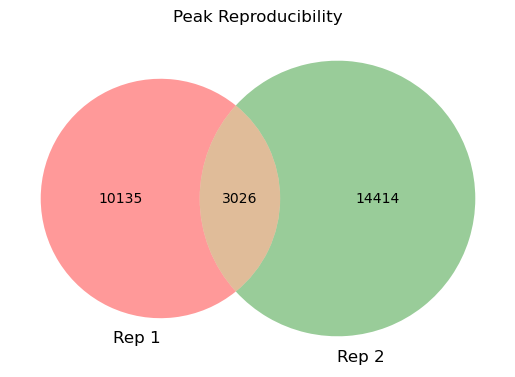

In [25]:
venn2(subsets=(unique_rep1, unique_rep2, 3026), set_labels=('Rep 1', 'Rep 2'))
plt.title("Peak Reproducibility")
plt.show()

### Analyzed Peaks Analysis

#### Methodology

I refined the annotated peaks to only look into the peaks that are associated with differentially expressed genes (padj < 0.01 & abs(log2FC) > 1). From there, I extracted the genes associated with these peaks and converted them to a list. I put these gene names into DAVID GO Analysis tool to understand which gene ontology pathways are being enriched. DAVID returned a Functional Annotation Chart that provided insight pathways that are being enriched and their interpretable annotation terms. I decided to focus on pathways that meet a significance threshold of P-value < 0.01. I chose a strict threshold to garner confidence in these results. I visualized results to show the number of DE genes that fall into each enriched pathway in ascending order of their p-value.


#### Results

In the bar chart we observe that there are only 7 pathways that are significantly enriched (p-value < 0.01). Three of these categories involve over 30 genes: Acetylation, Nucleus, and Phosphoprotein. The acetylation and phosphoprotein pathways are involved in post-translational modifications, which means these genes are involved with altering and regulating gene expression. In the scope of this paper, which zooms in on a cancer-related TF, these results make sense. The TF would need partners that are involved in regulating gene expression in order to make these processes go haywire and progress the cancer.

In [28]:
peaks.head()

,PeakID (cmd=annotatePeaks.pl refined_peaks.bed GRCh38.primary_assembly.genome.fa -gtf gencode.v45.primary_assembly.annotation.gtf),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
0,rep1_peak_933,chr1,146228817,146229331,+,3013,NaN,promoter-TSS (ENST00000362074.8),protein_coding-promoter-TSS (ENST00000362074.8),-33.0,ENST00000687833.1,ENSG00000264343,ENST00000686973,NaN,NaN,NOTCH2NLA,NaN,NaN,protein_coding
1,rep1_peak_956,chr1,148679264,148680120,+,2856,NaN,promoter-TSS (ENST00000593495.4),protein_coding-promoter-TSS (ENST00000593495.4),50.0,ENST00000606877.2,ENSG00000270629,ENST00000619423,NaN,NaN,NBPF14,NaN,NaN,protein_coding
2,rep1_peak_967,chr1,149390247,149390764,+,2435,NaN,promoter-TSS (ENST00000621744.4),protein_coding-promoter-TSS (ENST00000621744.4),-116.0,ENST00000650865.2,ENSG00000286219,ENST00000650865,NaN,NaN,NOTCH2NLC,NaN,NaN,protein_coding
3,rep1_peak_740,chr1,120069178,120070015,+,2198,NaN,promoter-TSS (ENST00000256646.7),protein_coding-promoter-TSS (ENST00000256646.7),20.0,ENST00000652302.1,ENSG00000134250,ENST00000640021,NaN,NaN,NOTCH2,NaN,NaN,protein_coding
4,rep1_peak_3996,chr15,70462699,70463421,+,1900,NaN,Intergenic,Intergenic,42868.0,ENST00000559752.1,ENSG00000259473,ENST00000559752,NaN,NaN,LINC02205,NaN,NaN,lncRNA


In [34]:
de_genes = rnaseq.query('padj < .01 & abs(log2FoldChange) > 1')['genename'].tolist()
de_peaks = peaks.query('`Gene Name` in @de_genes')

In [36]:
peaks_genes = de_peaks['Gene Name'].tolist()

In [37]:
file_path = "refs/peaks_genes.txt"

with open(file_path, "w") as file:
    for item in peaks_genes:
        file.write(str(item) + "\n")

print(f"List successfully written to {file_path}")

List successfully written to refs/peaks_genes.txt


#### Threw the gene list into DAVID and downloaded results of GO terms

In [39]:
terms = pd.read_csv('refs/DAVID_terms.txt', sep='\t')
terms_05 = terms[(terms['PValue']<0.01)]
terms_05

,Category,Term,Count,%,PValue,Genes,List Total,Pop Hits,Pop Total,Fold Enrichment,Bonferroni,Benjamini,FDR
0,GOTERM_BP_DIRECT,GO:0071456~cellular response to hypoxia,6,6.250000,0.000425,"CCNA2, BRIP1, ADAM8, MALAT1, BMP7, VASN",88,141,19478,9.418762,0.276951,0.324209,0.324209
1,UP_KW_PTM,KW-0007~Acetylation,32,33.333333,0.000430,"MCM7, HSPB1, LMNB1, TUBA1C, FAM156A, BRIP1, LG...",73,3515,14316,1.785350,0.008142,0.008604,0.008604
2,GOTERM_CC_DIRECT,GO:0005634~nucleus,42,43.750000,0.001315,"MESP2, CREBZF, NFIX, MCM7, HSPB8, HSPB1, USP18...",91,6244,20795,1.537106,0.242448,0.277480,0.277480
3,UP_KW_PTM,KW-0597~Phosphoprotein,55,57.291667,0.003190,"CREBZF, MCM7, CRYBG3, HSPB8, HSPB1, LMNB1, ROB...",73,8435,14316,1.278723,0.058908,0.031904,0.031904
4,UP_SEQ_FEATURE,COMPBIAS:Pro residues,19,19.791667,0.003432,"GRB7, NFIX, IQSEC1, KLHL17, HSPB1, INHBB, ARID...",89,2133,20675,2.069275,0.862887,1.000000,1.000000
5,UP_SEQ_FEATURE,MOTIF:Nuclear localization signal,8,8.333333,0.003690,"BRIP1, EXO1, ARID1A, SGK1, KPNA2, LPIN3, LMNB1...",89,465,20675,3.996617,0.881997,1.000000,1.000000
6,GOTERM_MF_DIRECT,GO:0016301~kinase activity,6,6.250000,0.004056,"LYN, PKM, CALM3, SGK1, MAPK8IP3, CDKN3",90,227,19253,5.654332,0.711654,1.000000,1.000000
7,GOTERM_BP_DIRECT,GO:0051301~cell division,7,7.291667,0.008722,"CCNA2, TUBA1C, PTTG1, KIFC1, PLK1, NUF2, LIG4",88,397,19478,3.902736,0.998749,1.000000,1.000000


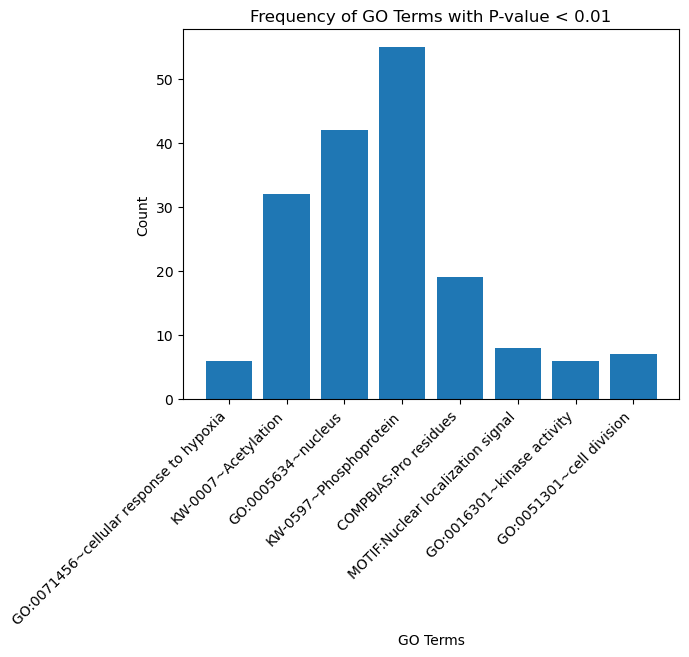

In [40]:
plt.bar(terms_05['Term'], terms_05['Count'])
plt.title('Frequency of GO Terms with P-value < 0.01')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('GO Terms')
plt.ylabel('Count')

plt.show()